# 1. Import and Hardware Setup

In [18]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import time
import copy

!pip install tqdm -q
from tqdm.auto import tqdm

!pip install wandb -q
import wandb
from IPython.display import clear_output, display

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [20]:
DATA_PATH = './Data'
SAVE_PATH = './Model'

In [21]:
# Login Weight & Bias
wandb.login()

True

# 2. Hyperparameters

In [22]:
BATCH_SIZE = 32
IMG_SIZE = 224
IMG_CHANNELS = 3
NUM_CLASSES = 101

EPOCHS = 50
LR = 0.01
DROPOUT_RATE = 0.5

# 3. Dataset Preparation

In [23]:
stats = ((0.545, 0.443, 0.344), (0.269, 0.271, 0.276))

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [24]:
# Load the full train data
full_train_data = datasets.Food101(root=DATA_PATH, download=True, split='train', transform=train_transform)

# Split the full train data into train and validation data
train_size = int(0.8 * len(full_train_data))
val_size = len(full_train_data) - train_size

train_subset, val_subset = random_split(full_train_data, (train_size, val_size))

# Change transform von val_subset to test_transform
val_subset.dataset = copy.copy(full_train_data)
val_subset.dataset.transform = test_transform

# Load Test Dataset
test_dataset = datasets.Food101(root=DATA_PATH, download=True, split='test', transform=test_transform)

In [25]:
# Loader
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=4, pin_memory=True, persistent_workers=True)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=4, pin_memory=True, persistent_workers=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=4, pin_memory=True, persistent_workers=True)



# 4. ZFNet Architecture

In [26]:
class ZFNet(nn.Module):
    def __init__(self, in_channels, num_classes, dropout_rate):
        super().__init__()
        # Conv 1: 224x224 -> 110x110
        self.conv1 = nn.Conv2d(in_channels, 96, kernel_size=7, stride=2, padding=1)
        self.relu1 = nn.ReLU(inplace=False)
        self.lrn1 = nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1, return_indices=True)

        # Conv 2: 55x55 -> 26x26
        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, stride=2, padding=0)
        self.relu2 = nn.ReLU(inplace=False)
        self.lrn2 = nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1, return_indices=True)

        # Layers 3-5
        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU(inplace=False)
        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU(inplace=False)
        self.conv5 = nn.Conv2d(384, 256, kernel_size=3, padding=1)
        self.relu5 = nn.ReLU(inplace=False)
        self.pool3 = nn.MaxPool2d(kernel_size=3, stride=2, return_indices=True)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        self.activations = []
        self.indices = []
        self.pool_sizes = [] # To store the size before each pooling

        # Layer 1
        x = self.relu1(self.conv1(x))
        x = self.lrn1(x)
        self.activations.append(x.clone())
        self.pool_sizes.append(x.size())
        x, i1 = self.pool1(x)
        self.indices.append(i1)

        # Layer 2
        x = self.relu2(self.conv2(x))
        x = self.lrn2(x)
        self.activations.append(x.clone())
        self.pool_sizes.append(x.size())
        x, i2 = self.pool2(x)
        self.indices.append(i2)

        # Layers 3-4
        x = self.relu3(self.conv3(x))
        self.activations.append(x.clone())
        x = self.relu4(self.conv4(x))
        self.activations.append(x.clone())

        # Layer 5
        x = self.relu5(self.conv5(x))
        self.activations.append(x.clone())
        self.pool_sizes.append(x.size())
        x, i3 = self.pool3(x)
        self.indices.append(i3)
        
        x = torch.flatten(x, 1)
        return self.classifier(x)

model = ZFNet(IMG_CHANNELS, NUM_CLASSES, DROPOUT_RATE).to(device)

# 5. Training

In [27]:
import numpy as np

class EarlyStopping:
    """ Early stops the training if validation loss doesn't improve after 
        a given patience.
    """
    def __init__(self, patience=5, verbose=False, delta=0, save_path='best_checkpoint.pth', 
                                            trace_func=print):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.save_path = save_path
        self.trace_func = trace_func
        
        self.counter = 0
        self.best_score = None
        self.val_loss_min = np.inf
        self.early_stop = False

    def __call__(self, val_loss, model):

        # 1. First epoch
        if self.best_score is None:
            self.best_score = val_loss
            self.save_checkpoint(val_loss, model)

        # 2. If the validation loss is larger than the best score
        # -> Increase the counter
        elif val_loss > self.best_score - self.delta:
            self.counter += 1
            self.trace_func(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

        # 3. The Validation Loss reduced -> Save the model
        else:
            self.best_score = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        self.val_loss_min = val_loss
        torch.save(model.state_dict(), self.save_path)

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.1)

# Using GradScaler to prevent Gradient Underflow when using FP16
scaler = torch.amp.GradScaler(device)

In [29]:
def train(model, loader, criterion, optimizer, scheduler):
    # Set the model into train mode
    model.train()
    
    # Define the loss and acc
    train_loss, correct = 0, 0

    # Create Loading Progress with
    loop = tqdm(loader, desc="Training", leave=False)

    # Loop through the loop
    for x, y in loop:
        # Move training data to device
        x, y = x.to(device), y.to(device)

        # Clear the gradients of last batch, set to None to save memory
        optimizer.zero_grad(set_to_none=True)

        # 
        with torch.amp.autocast(device_type=device.type):
            # get the prediction
            out = model(x)
            # Calculate loss
            loss = criterion(out, y)

        # Scaling the loss -> Backpropagation
        scaler.scale(loss).backward()
        # scaler.scale(loss): multiplies the loss by a larger "scale factor"
        # -> The loss becomes larger, moving them out of the "underflow zone"
        # .backward(): performs the standard backpropagation

        # Unscale before clipping
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Unscale the gradients before the optimizer updates the weights
        scaler.step(optimizer)

        # Adjusts the scale factor for the next batch
        scaler.update()

        train_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()

    return train_loss / len(loader.dataset), correct / len(loader.dataset)

In [30]:
def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0, 0

    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item() * x.size(0)
            val_acc += (out.argmax(1) == y).sum().item()

    return val_loss / len(loader.dataset), val_acc / len(loader.dataset)

In [31]:
def evaluate(model, loader):
    model.eval()
    eval_acc = 0

    loop = tqdm(loader, desc="Testing", leave=False)

    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)

            eval_acc += (out.argmax(1) == y).sum().item()

    return eval_acc / len(loader.dataset)

# 6. DeconvNet Visualization

In [34]:
class ZFDeconvNet(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.unpool3 = nn.MaxUnpool2d(kernel_size=3, stride=2)
        self.deconv5 = nn.ConvTranspose2d(256, 384, kernel_size=3, padding=1)
        self.deconv4 = nn.ConvTranspose2d(384, 384, kernel_size=3, padding=1)
        self.deconv3 = nn.ConvTranspose2d(384, 256, kernel_size=3, padding=1)
        self.unpool2 = nn.MaxUnpool2d(kernel_size=3, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(256, 96, kernel_size=5, stride=2, padding=0)
        self.unpool1 = nn.MaxUnpool2d(kernel_size=3, stride=2, padding=1)
        self.deconv1 = nn.ConvTranspose2d(96, 3, kernel_size=7, stride=2, padding=1, output_padding=1)

        with torch.no_grad():
            self.deconv5.weight.copy_(model.conv5.weight)
            self.deconv4.weight.copy_(model.conv4.weight)
            self.deconv3.weight.copy_(model.conv3.weight)
            self.deconv2.weight.copy_(model.conv2.weight)
            self.deconv1.weight.copy_(model.conv1.weight)

    def forward(self, x, layer_num, indices, pool_sizes):
        if layer_num == 5:
            x = self.deconv5(F.relu(x))
            layer_num = 4
        if layer_num == 4:
            x = self.deconv4(F.relu(x))
            layer_num = 3
        if layer_num == 3:
            x = self.deconv3(F.relu(x))
            layer_num = 2
        if layer_num == 2:
            x = self.unpool2(x, indices[1], output_size=pool_sizes[1])
            x = self.deconv2(F.relu(x))
            layer_num = 1
        if layer_num == 1:
            x = self.unpool1(x, indices[0], output_size=pool_sizes[0])
            x = self.deconv1(F.relu(x))
        return x

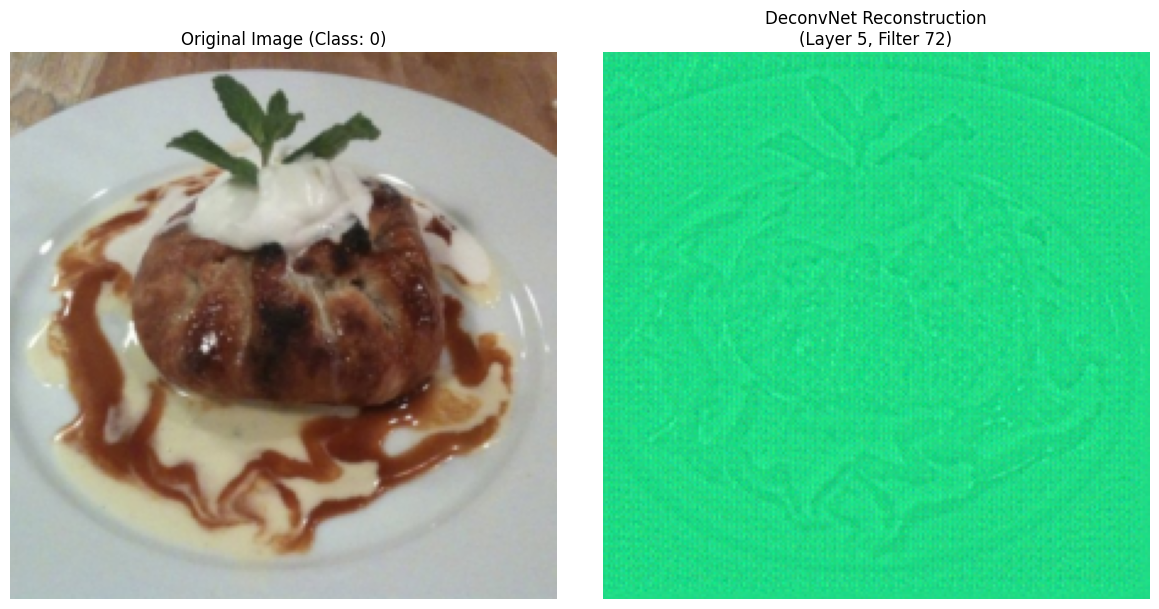

In [36]:
# --- Updated Visualization & Plotting Block ---
import numpy as np

def denormalize(img_tensor, stats):
    """ Correctly reverses the normalization for visualization """
    # Ensure stats are on the same device as the image
    mean = torch.tensor(stats[0]).view(3, 1, 1).to(img_tensor.device)
    std = torch.tensor(stats[1]).view(3, 1, 1).to(img_tensor.device)
    img = img_tensor * std + mean
    # Clip to [0, 1] to avoid imshow warnings/errors
    return img.permute(1, 2, 0).cpu().numpy().clip(0, 1)

def visualize_deconv(model, image, layer_num, filter_num):
    model.eval()
    deconv = ZFDeconvNet(model).to(device)
    
    # Forward pass to capture indices and activations
    with torch.no_grad():
        model(image.unsqueeze(0).to(device))
    
    # Get the activation for the target layer
    act = model.activations[layer_num - 1]
    
    # Isolate ONE specific filter for visualization
    target_act = torch.zeros_like(act)
    target_act[0, filter_num] = act[0, filter_num]
    
    # Run the backwards reconstruction
    with torch.no_grad():
        recon_tensor = deconv(target_act, layer_num, model.indices, model.pool_sizes)
    
    # Normalize the reconstruction to the [0, 1] range for display
    recon = recon_tensor[0].permute(1, 2, 0).cpu().numpy()
    recon = (recon - recon.min()) / (recon.max() - recon.min() + 1e-8)
    return recon

# 1. Pick an image from the test set
imgs, labels = next(iter(test_loader))
idx = 0 
img = imgs[idx]

# 2. Find the strongest activating filter in Layer 5 for this specific image
with torch.no_grad():
    model(img.unsqueeze(0).to(device))
    max_filter = model.activations[4][0].sum(dim=(1,2)).argmax().item()

# 3. Generate the reconstruction and the clean original image
recon = visualize_deconv(model, img, layer_num=5, filter_num=max_filter)
original_vis = denormalize(img, stats)

# 4. Final Plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_vis)
plt.title(f"Original Image (Class: {labels[idx].item()})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(recon)
plt.title(f"DeconvNet Reconstruction\n(Layer 5, Filter {max_filter})")
plt.axis('off')

plt.tight_layout()
plt.show()

In [32]:
import numpy as np

wandb.init(
    project = "ZFNet",
    config = {
        "Architecture": "ZFNet",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "image_size": IMG_SIZE
    }
)

train_accuracies, test_accuracies = [], []
train_losses, test_losses = [], []
early_stopping = EarlyStopping(patience=5, save_path='ZFNet_best_model.pth')

# --- Setup for Visualization History --- 
# 1. Pick a fixed image from the test set to watch throughout training
imgs, labels = next(iter(test_loader))
fixed_idx = 0
fixed_img = imgs[fixed_idx]
target_layer = 5
target_filter = 72 # Or any filter you want to watch

history_recons = [] # To store the images for the final grid

print(f"Tracking Evolution for Filter {target_filter} on Class {labels[fixed_idx].item()}")

# 2. Start the Training Loop
for epoch in range(EPOCHS):
    # Standard Training and Validation
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scheduler)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step(val_loss)
    test_acc = evaluate(model, test_loader)
    
    # Generate the reconstruction for the fixed image
    recon = visualize_deconv(model, fixed_img, target_layer, target_filter)
    history_recons.append(recon) # Save for final plot
    
    # Real-time Plotting in Notebook
    clear_output(wait=True)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(denormalize(fixed_img, stats))
    plt.title(f"Original Image (Class: {labels[fixed_idx].item()})")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(recon)
    plt.title(f"Epoch {epoch+1}: Layer {target_layer} Filter {target_filter}")
    plt.axis('off')
    plt.show()

    # Log metrics AND the reconstruction image to W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "lr": optimizer.param_groups[0]['lr'],
        "Feature_Evolution": wandb.Image(recon)
    })

    print(f"{epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}," +
                             f" train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}, test_acc: {test_acc:.4f}")

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early Stopping triggered.")
        break

wandb.finish()

# --- Final Step: Plot the Epoch History Grid ---
print("Training Complete! Here is the evolution grid across all epochs:")
plt.figure(figsize=(20, 10))
cols = 10
rows = (len(history_recons) + cols - 1) // cols
for i, img in enumerate(history_recons):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Ep {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()


Training:   0%|          | 0/1894 [00:00<?, ?it/s]

Validation:   0%|          | 0/474 [00:00<?, ?it/s]

Testing:   0%|          | 0/790 [00:00<?, ?it/s]

1/1: train_loss: 4.6163, val_loss: 4.6167, train_acc: 0.0094, val_acc: 0.0096, test_acc: 0.0099


epoch,▁
lr,▁
test_acc,▁
train_acc,▁
train_loss,▁
val_acc,▁
val_loss,▁
epoch,1
lr,0.01
test_acc,0.0099
train_acc,0.00944


# 7. Result Plot

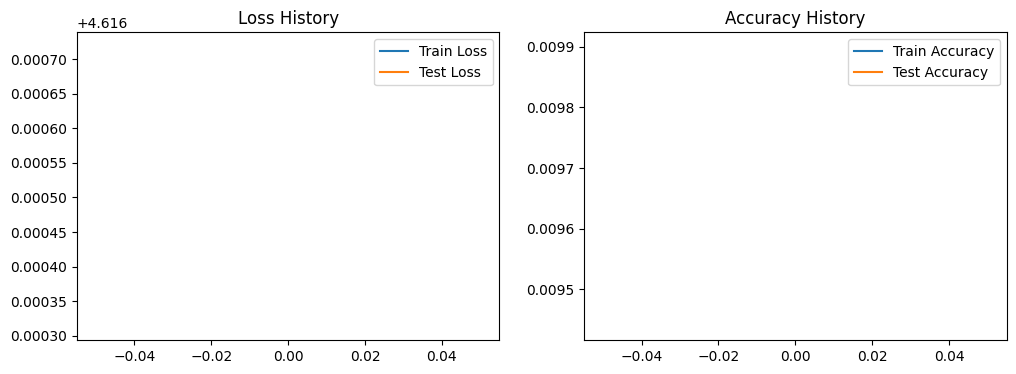

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Accuracy History')
plt.legend() 